In [13]:
import pandas as pd
import datetime
import matplotlib.pyplot as plt

In [14]:
# Get data between specified dates
def filter_times(df, time1, time2):
    return df.apply(lambda x: (time1 <= x['begin_time']) and (x['begin_time'] <= time2) , axis=1)

In [15]:
# Remove duplicate times by replacing with mean value and insert missing times

def process_begin_times(df):
    df['begin_time'] = pd.to_datetime(df['begin_time'])
    df.set_index('begin_time', inplace=True)
    df = df.groupby(df.index).mean()
    dates = pd.date_range(start=df.index.min(), end=df.index.max(), freq='1h')
    df = df.reindex(dates)
    df.reset_index(inplace=True)
    df.rename(columns={'index':'begin_time'}, inplace=True)
    return df 

In [16]:
# Load price datasets

day_ahead_price = pd.read_csv('Data/preprocessed/stacked_lmp_da_hr_data.csv')
day_ahead_price.rename(columns={'Local Timestamp Pacific Time (Interval Beginning)': 'begin_time'}, inplace=True)
day_ahead_price = day_ahead_price[['begin_time','NP-15 LMP', 'SP-15 LMP']]
day_ahead_price = process_begin_times(day_ahead_price)
real_time_price = pd.read_csv('Data/preprocessed/stacked_lmp_price_data.csv')
real_time_price.rename(columns={'Local Timestamp Pacific Time (Interval Beginning)': 'begin_time'}, inplace=True)
real_time_price = real_time_price[['begin_time','NP-15 LMP', 'SP-15 LMP']]
real_time_price = process_begin_times(real_time_price)
nat_gas_price = pd.read_csv('Data/preprocessed/nat_gas_price.csv')

In [17]:
power_price_data = pd.merge(day_ahead_price, real_time_price, how='inner', on='begin_time', suffixes=['_da', '_rt'])
nat_gas_price['begin_time'] = pd.to_datetime(nat_gas_price['begin_time'])
price_data = pd.merge(power_price_data, nat_gas_price[['begin_time', 'Natural_gas_price']], how='inner', on='begin_time')
price_data

,begin_time,NP-15 LMP_da,SP-15 LMP_da,NP-15 LMP_rt,SP-15 LMP_rt,Natural_gas_price
0,2021-01-01 00:00:00,34.02723,33.48613,30.76070,30.11292,2.39
1,2021-01-01 01:00:00,32.25537,31.58175,29.89887,29.26924,2.39
2,2021-01-01 02:00:00,33.48902,32.63983,28.47212,27.87253,2.39
3,2021-01-01 03:00:00,32.79130,31.97649,29.79934,29.17180,2.39
4,2021-01-01 04:00:00,34.10638,33.15344,29.26075,28.64456,2.39
...,...,...,...,...,...,...
35059,2024-12-31 19:00:00,52.95726,51.32403,47.43169,46.97551,3.40
35060,2024-12-31 20:00:00,52.41941,51.57697,46.46807,45.63533,3.40
35061,2024-12-31 21:00:00,52.23158,50.44737,44.37653,43.81899,3.40
35062,2024-12-31 22:00:00,51.55114,50.00000,46.56593,45.68607,3.40


In [18]:
priceNaNs = price_data.groupby(price_data['begin_time'].apply(lambda x : x.date())).apply(lambda g: g.isna().sum())
priceNaNs['NP-15 LMP_da'].value_counts()
#priceNaNs[priceNaNs['NP-15 LMP_da']==24]

NP-15 LMP_da
0     1384
24      73
1        4
Name: count, dtype: int64

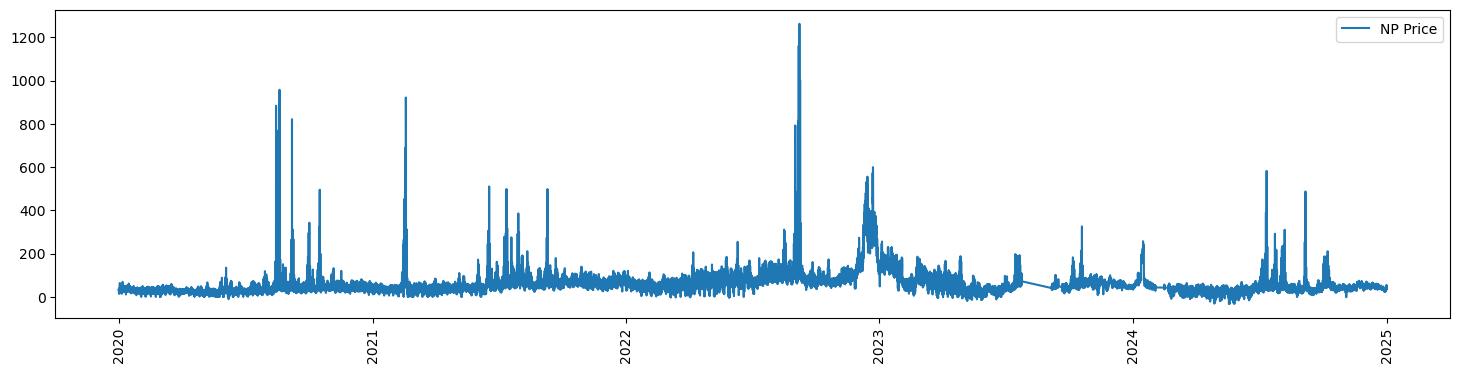

In [19]:
day_ahead_price = pd.read_csv('Data/preprocessed/stacked_lmp_da_hr_data.csv')
day_ahead_price.rename(columns={'Local Timestamp Pacific Time (Interval Beginning)': 'begin_time'}, inplace=True)
day_ahead_price['begin_time'] = pd.to_datetime(day_ahead_price['begin_time'])

time1 = datetime.datetime(2023, 7, 12, 0, 0, 0)
time2 = datetime.datetime(2024, 1, 17, 0, 0, 0)

#filtered_data = price_data[filter_times(price_data, time1, time2)]

plt.figure(figsize=(18, 4))
#plt.plot(filtered_data['begin_time'], filtered_data['SP-15 LMP_da'] , label='SP Price')
plt.plot(day_ahead_price['begin_time'], day_ahead_price['NP-15 LMP'] , label='NP Price')

plt.xticks(rotation=90)
plt.legend()
plt.show()

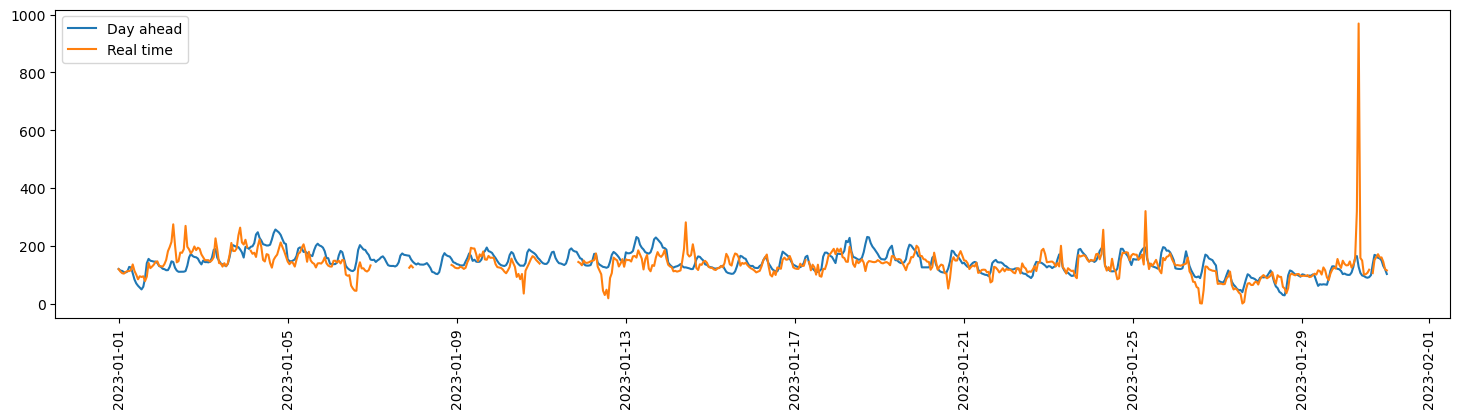

In [20]:
time1 = datetime.datetime(2023, 1, 1, 0, 0, 0)
time2 = datetime.datetime(2023, 1, 31, 0, 0, 0)

plt.figure(figsize=(18, 4))
plt.plot(price_data[filter_times(price_data, time1, time2)]['begin_time'], price_data[filter_times(price_data, time1, time2)]['NP-15 LMP_da'], label='Day ahead')
plt.plot(price_data[filter_times(price_data, time1, time2)]['begin_time'], price_data[filter_times(price_data, time1, time2)]['NP-15 LMP_rt'], label='Real time')

plt.xticks(rotation=90)
plt.legend()
plt.show()

In [21]:
klamath_river_data = pd.read_csv('Data/preprocessed/klamath_river_discharge.csv')
sacramento_river_data = pd.read_csv('Data/preprocessed/sacramento_river_discharge.csv')
river_discharge_data = pd.merge(klamath_river_data, sacramento_river_data, on='begin_time', how='outer', suffixes=['_klamath', '_sacramento'])
river_discharge_data = process_begin_times(river_discharge_data)
river_discharge_data

,begin_time,flow_klamath,flow_sacramento
0,2020-01-01 00:00:00,5670.0,18200.0
1,2020-01-01 01:00:00,5670.0,18500.0
2,2020-01-01 02:00:00,5640.0,19100.0
3,2020-01-01 03:00:00,5670.0,19000.0
4,2020-01-01 04:00:00,5690.0,19100.0
...,...,...,...
43867,2025-01-01 19:00:00,79900.0,55500.0
43868,2025-01-01 20:00:00,81100.0,56100.0
43869,2025-01-01 21:00:00,81900.0,55800.0
43870,2025-01-01 22:00:00,83000.0,56000.0


In [22]:
price_river_data = pd.merge(price_data, river_discharge_data, on='begin_time', how='inner')
price_river_data

,begin_time,NP-15 LMP_da,SP-15 LMP_da,NP-15 LMP_rt,SP-15 LMP_rt,Natural_gas_price,flow_klamath,flow_sacramento
0,2021-01-01 00:00:00,34.02723,33.48613,30.76070,30.11292,2.39,10100.0,13500.0
1,2021-01-01 01:00:00,32.25537,31.58175,29.89887,29.26924,2.39,10100.0,13900.0
2,2021-01-01 02:00:00,33.48902,32.63983,28.47212,27.87253,2.39,10000.0,13900.0
3,2021-01-01 03:00:00,32.79130,31.97649,29.79934,29.17180,2.39,10000.0,13700.0
4,2021-01-01 04:00:00,34.10638,33.15344,29.26075,28.64456,2.39,9970.0,12400.0
...,...,...,...,...,...,...,...,...
35059,2024-12-31 19:00:00,52.95726,51.32403,47.43169,46.97551,3.40,84500.0,54300.0
35060,2024-12-31 20:00:00,52.41941,51.57697,46.46807,45.63533,3.40,83100.0,54900.0
35061,2024-12-31 21:00:00,52.23158,50.44737,44.37653,43.81899,3.40,81900.0,54600.0
35062,2024-12-31 22:00:00,51.55114,50.00000,46.56593,45.68607,3.40,81100.0,55000.0


In [23]:
pge_load = pd.read_csv('Data/load_1hr_PGE.csv')
pge_load.rename(columns={'interval_start_local':'begin_time'}, inplace=True)
sce_load = pd.read_csv('Data/load_1hr_SCE.csv')
sce_load.rename(columns={'interval_start_local':'begin_time'}, inplace=True)
load_data = pd.merge(pge_load[['begin_time', 'load']], sce_load[['begin_time', 'load']], on='begin_time', how='outer', suffixes=['_PGE', '_SCE'])
load_data['begin_time'] = pd.to_datetime(load_data['begin_time']).apply(lambda x : x.tz_localize(None))
load_data = process_begin_times(load_data)
load_data

/var/folders/y1/qbgxvx6j1vj5ydy42yxx7fsm0000gn/T/ipykernel_37125/1066887138.py:6: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  load_data['begin_time'] = pd.to_datetime(load_data['begin_time']).apply(lambda x : x.tz_localize(None))


,begin_time,load_PGE,load_SCE
0,2020-01-01 00:00:00,10206.0,9184.0
1,2020-01-01 01:00:00,9866.0,8876.0
2,2020-01-01 02:00:00,9605.0,8667.0
3,2020-01-01 03:00:00,9453.0,8563.0
4,2020-01-01 04:00:00,9389.0,8562.0
...,...,...,...
43843,2024-12-31 19:00:00,11307.0,10952.0
43844,2024-12-31 20:00:00,10967.0,10667.0
43845,2024-12-31 21:00:00,10614.0,10503.0
43846,2024-12-31 22:00:00,10226.0,10237.0


In [24]:
load_forecast = pd.read_csv('Data/preprocessed/stacked_load_forecast_data.csv', usecols=['Local Timestamp Pacific Time (Interval Beginning)', 'Pacific Gas and Electric Forecast Load (MW)', 'Southern California Edison Forecast Load (MW)'])
load_forecast.rename(columns={'Local Timestamp Pacific Time (Interval Beginning)':'begin_time'}, inplace=True)
load_forecast=process_begin_times(load_forecast)
load_forecast
load_all = pd.merge(load_data, load_forecast, on='begin_time', how='inner')
load_all

,begin_time,load_PGE,load_SCE,Pacific Gas and Electric Forecast Load (MW),Southern California Edison Forecast Load (MW)
0,2021-03-12 00:00:00,9914.0,9763.0,10102.72,9686.47
1,2021-03-12 01:00:00,9827.0,9536.0,9868.57,9474.64
2,2021-03-12 02:00:00,9849.0,9416.0,9712.50,9339.19
3,2021-03-12 03:00:00,9939.0,9475.0,9715.76,9304.25
4,2021-03-12 04:00:00,10287.0,9842.0,9969.51,9545.95
...,...,...,...,...,...
33379,2024-12-31 19:00:00,11307.0,10952.0,11959.79,10989.78
33380,2024-12-31 20:00:00,10967.0,10667.0,11723.02,10760.92
33381,2024-12-31 21:00:00,10614.0,10503.0,11408.80,10646.09
33382,2024-12-31 22:00:00,10226.0,10237.0,10831.46,10435.11


In [25]:
price_river_load_data = pd.merge(price_river_data, load_all, on='begin_time', how='inner')
price_river_load_data

,begin_time,NP-15 LMP_da,SP-15 LMP_da,NP-15 LMP_rt,SP-15 LMP_rt,Natural_gas_price,flow_klamath,flow_sacramento,load_PGE,load_SCE,Pacific Gas and Electric Forecast Load (MW),Southern California Edison Forecast Load (MW)
0,2021-03-12 00:00:00,42.96548,40.78043,34.56084,33.48478,2.65,11900.0,14800.0,9914.0,9763.0,10102.72,9686.47
1,2021-03-12 01:00:00,39.48897,37.76416,33.10504,32.01413,2.65,11900.0,14400.0,9827.0,9536.0,9868.57,9474.64
2,2021-03-12 02:00:00,39.09879,37.50715,34.53900,33.43611,2.65,11900.0,12500.0,9849.0,9416.0,9712.50,9339.19
3,2021-03-12 03:00:00,39.38309,37.79894,33.62841,32.36996,2.65,11900.0,8930.0,9939.0,9475.0,9715.76,9304.25
4,2021-03-12 04:00:00,41.92228,40.13255,34.56917,33.48674,2.65,11800.0,6770.0,10287.0,9842.0,9969.51,9545.95
...,...,...,...,...,...,...,...,...,...,...,...,...
33379,2024-12-31 19:00:00,52.95726,51.32403,47.43169,46.97551,3.40,84500.0,54300.0,11307.0,10952.0,11959.79,10989.78
33380,2024-12-31 20:00:00,52.41941,51.57697,46.46807,45.63533,3.40,83100.0,54900.0,10967.0,10667.0,11723.02,10760.92
33381,2024-12-31 21:00:00,52.23158,50.44737,44.37653,43.81899,3.40,81900.0,54600.0,10614.0,10503.0,11408.80,10646.09
33382,2024-12-31 22:00:00,51.55114,50.00000,46.56593,45.68607,3.40,81100.0,55000.0,10226.0,10237.0,10831.46,10435.11


In [26]:
np15_renforecast = pd.read_csv('Data/solarwind_forecast_1hr_NP15.csv')
np15_renforecast.rename(columns={'interval_start_local':'begin_time'}, inplace=True)
np15_renforecast = np15_renforecast.groupby('begin_time').last()
np15_renforecast.reset_index(inplace=True)
np15_renforecast.rename(columns={'index':'begin_time'}, inplace=True)
sp15_renforecast = pd.read_csv('Data/solarwind_forecast_1hr_SP15.csv')
sp15_renforecast.rename(columns={'interval_start_local':'begin_time'}, inplace=True)
sp15_renforecast = sp15_renforecast.groupby('begin_time').last()
sp15_renforecast.reset_index(inplace=True)
sp15_renforecast.rename(columns={'index':'begin_time'}, inplace=True)

In [27]:
renforecast_data = pd.merge(np15_renforecast[['begin_time', 'solar_mw', 'wind_mw']], sp15_renforecast[['begin_time', 'solar_mw', 'wind_mw']], on='begin_time', how='outer', suffixes=['_NP15', '_SP15'])
renforecast_data['begin_time'] = pd.to_datetime(renforecast_data['begin_time']).apply(lambda x : x.tz_localize(None))
renforecast_data

/var/folders/y1/qbgxvx6j1vj5ydy42yxx7fsm0000gn/T/ipykernel_37125/717681725.py:2: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  renforecast_data['begin_time'] = pd.to_datetime(renforecast_data['begin_time']).apply(lambda x : x.tz_localize(None))


,begin_time,solar_mw_NP15,wind_mw_NP15,solar_mw_SP15,wind_mw_SP15
0,2021-01-01 00:00:00,0.00,99.27,0.00,358.53
1,2021-01-01 01:00:00,0.00,68.52,0.00,357.90
2,2021-01-01 02:00:00,0.00,59.47,0.00,353.44
3,2021-01-01 03:00:00,0.00,59.21,0.00,347.50
4,2021-01-01 04:00:00,0.00,48.41,0.00,334.32
...,...,...,...,...,...
37026,2025-03-23 19:00:00,4.86,100.60,0.35,291.40
37027,2025-03-23 20:00:00,0.00,144.92,0.00,301.57
37028,2025-03-23 21:00:00,0.00,170.87,0.00,254.85
37029,2025-03-23 22:00:00,0.00,184.65,0.00,199.49


In [28]:
ren_gen_actual = pd.read_csv('Data/preprocessed/stacked_gen_ren_hr_data.csv', usecols=['Local Timestamp Pacific Time (Interval Beginning)','NP15 Solar Generation (MW)','SP15 Solar Generation (MW)','NP15 Wind Generation (MW)','SP15 Wind Generation (MW)','ZP26 Wind Generation (MW)'])
ren_gen_actual.rename(columns={'Local Timestamp Pacific Time (Interval Beginning)':'begin_time'}, inplace=True)
ren_gen_actual = process_begin_times(ren_gen_actual)
ren_all = pd.merge(renforecast_data, ren_gen_actual[['begin_time', 'NP15 Solar Generation (MW)', 'SP15 Solar Generation (MW)', 'NP15 Wind Generation (MW)', 'SP15 Wind Generation (MW)']], on='begin_time', how='inner')
ren_all

,begin_time,solar_mw_NP15,wind_mw_NP15,solar_mw_SP15,wind_mw_SP15,NP15 Solar Generation (MW),SP15 Solar Generation (MW),NP15 Wind Generation (MW),SP15 Wind Generation (MW)
0,2021-01-01 00:00:00,0.0,99.27,0.0,358.53,-3.88458,-26.26146,179.27404,646.89379
1,2021-01-01 01:00:00,0.0,68.52,0.0,357.90,-3.91677,-26.16373,97.43401,833.29945
2,2021-01-01 02:00:00,0.0,59.47,0.0,353.44,-3.94931,-26.17962,41.32052,964.35413
3,2021-01-01 03:00:00,0.0,59.21,0.0,347.50,-3.95021,-27.53725,20.37190,791.57957
4,2021-01-01 04:00:00,0.0,48.41,0.0,334.32,-3.96713,-28.15593,43.17521,821.80986
...,...,...,...,...,...,...,...,...,...
35059,2024-12-31 19:00:00,0.0,48.25,0.0,455.97,-3.03842,-37.67855,58.35641,29.42005
35060,2024-12-31 20:00:00,0.0,55.64,0.0,443.61,-7.19792,-37.10158,65.56839,32.46489
35061,2024-12-31 21:00:00,0.0,65.90,0.0,427.09,-6.79170,-37.17194,62.77812,27.18265
35062,2024-12-31 22:00:00,0.0,77.46,0.0,344.13,-6.26466,-37.52891,54.79276,39.90553


In [29]:
price_river_load_ren_data = pd.merge(price_river_load_data, ren_all, on='begin_time', how='inner')
price_river_load_ren_data.to_csv('ITSUR_data.csv', index=False)
price_river_load_ren_data

,begin_time,NP-15 LMP_da,SP-15 LMP_da,NP-15 LMP_rt,SP-15 LMP_rt,Natural_gas_price,flow_klamath,flow_sacramento,load_PGE,load_SCE,Pacific Gas and Electric Forecast Load (MW),Southern California Edison Forecast Load (MW),solar_mw_NP15,wind_mw_NP15,solar_mw_SP15,wind_mw_SP15,NP15 Solar Generation (MW),SP15 Solar Generation (MW),NP15 Wind Generation (MW),SP15 Wind Generation (MW)
0,2021-03-12 00:00:00,42.96548,40.78043,34.56084,33.48478,2.65,11900.0,14800.0,9914.0,9763.0,10102.72,9686.47,0.0,327.97,0.0,1062.94,-2.69832,-26.29464,526.78168,713.36328
1,2021-03-12 01:00:00,39.48897,37.76416,33.10504,32.01413,2.65,11900.0,14400.0,9827.0,9536.0,9868.57,9474.64,0.0,259.94,0.0,1018.10,-2.66009,-26.30124,405.97186,583.05445
2,2021-03-12 02:00:00,39.09879,37.50715,34.53900,33.43611,2.65,11900.0,12500.0,9849.0,9416.0,9712.50,9339.19,0.0,191.44,0.0,974.17,-2.68074,-26.46864,288.43194,730.31104
3,2021-03-12 03:00:00,39.38309,37.79894,33.62841,32.36996,2.65,11900.0,8930.0,9939.0,9475.0,9715.76,9304.25,0.0,148.07,0.0,935.87,-2.68692,-29.03769,205.85381,709.88240
4,2021-03-12 04:00:00,41.92228,40.13255,34.56917,33.48674,2.65,11800.0,6770.0,10287.0,9842.0,9969.51,9545.95,0.0,134.36,0.0,908.84,-2.58009,-29.40176,173.78675,661.02222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33379,2024-12-31 19:00:00,52.95726,51.32403,47.43169,46.97551,3.40,84500.0,54300.0,11307.0,10952.0,11959.79,10989.78,0.0,48.25,0.0,455.97,-3.03842,-37.67855,58.35641,29.42005
33380,2024-12-31 20:00:00,52.41941,51.57697,46.46807,45.63533,3.40,83100.0,54900.0,10967.0,10667.0,11723.02,10760.92,0.0,55.64,0.0,443.61,-7.19792,-37.10158,65.56839,32.46489
33381,2024-12-31 21:00:00,52.23158,50.44737,44.37653,43.81899,3.40,81900.0,54600.0,10614.0,10503.0,11408.80,10646.09,0.0,65.90,0.0,427.09,-6.79170,-37.17194,62.77812,27.18265
33382,2024-12-31 22:00:00,51.55114,50.00000,46.56593,45.68607,3.40,81100.0,55000.0,10226.0,10237.0,10831.46,10435.11,0.0,77.46,0.0,344.13,-6.26466,-37.52891,54.79276,39.90553
